In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io as sio
import xml.etree.ElementTree as ET
from scipy.optimize import curve_fit
from scipy.special import erf, erfinv
import warnings

import RamanHelpers as rh

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "figure.dpi"       : 150,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Save helper ───────────────────────────────────────────────────────────────
SAVE_FILE = "linescan_results.npz"

def save_results(**kwargs):
    """
    Incrementally update linescan_results.npz with new key-value pairs.
    Loads existing data first so no previous results are lost.
    """
    store = dict(np.load(SAVE_FILE, allow_pickle=True)) \
            if os.path.exists(SAVE_FILE) else {}
    store.update(kwargs)
    np.savez(SAVE_FILE, **store)
    keys = list(kwargs.keys())
    print(f"  ✓ Saved {len(keys)} variable(s) → {SAVE_FILE}")
    print(f"    {keys}")

print("Imports OK")
print(f"Save file  : {SAVE_FILE}")
print(f"rh version : {rh.__file__}")

Imports OK
Save file  : linescan_results.npz
rh version : /Users/egeeroglu/Desktop/RIRO/Tuesday/RamanData/RamanHelpers.py


In [3]:
# ── Cell 1b: Additional helpers not in raman_helpers.py ──────────────────────
# These are specific to the knife-edge / spot size analysis and don't
# belong in the general raman_helpers module.

def normalise_profile(intensity, low_pct=5, high_pct=95):
    """
    Normalise a Si intensity profile to 0→1 using robust percentiles.
    Uses percentiles rather than min/max to avoid single noisy spectra
    distorting the scale.

    Parameters
    ----------
    intensity : 1-D array, Si peak amplitudes across the line scan
    low_pct   : percentile used as chrome (zero) level (default 5)
    high_pct  : percentile used as Si (full) level   (default 95)

    Returns
    -------
    norm : 1-D array clipped to [0, 1]
    """
    i_bg  = np.percentile(intensity[~np.isnan(intensity)], low_pct)
    i_si  = np.percentile(intensity[~np.isnan(intensity)], high_pct)
    return np.clip((intensity - i_bg) / (i_si - i_bg), 0, 1)


def find_edge_window(pos, norm, pad=35):
    """
    Locate the transition region in a normalised edge profile and return
    a fitting window centred on the steepest point.

    Parameters
    ----------
    pos  : 1-D array, physical positions (µm)
    norm : 1-D array, normalised intensity [0, 1]
    pad  : number of steps on each side of the steepest point (default 35)

    Returns
    -------
    p_fit : cropped position array
    n_fit : cropped normalised intensity array
    peak_idx : index of steepest point in the original arrays
    """
    deriv    = np.gradient(norm, pos)
    peak_idx = np.argmax(deriv)
    s        = max(0, peak_idx - pad)
    e        = min(len(pos), peak_idx + pad)
    return pos[s:e], norm[s:e], peak_idx


def beam_size_from_w(w):
    """
    Compute all common beam size metrics from the Araújo 1/e radius w.

    Parameters
    ----------
    w : float, 1/e intensity radius (µm) — Araújo Eq.(1) convention

    Returns
    -------
    dict with keys:
        w         : 1/e   radius (µm)
        w_1e2     : 1/e²  radius (µm) = w × √2
        fwhm      : FWHM  (µm)        = 2√(ln2) × w
        w_1090    : 10%→90% width (µm) = 2 × erfinv(0.8) × w
    """
    return {
        "w"     : w,
        "w_1e2" : w * np.sqrt(2),
        "fwhm"  : 2 * np.sqrt(np.log(2)) * w,
        "w_1090": 2 * erfinv(0.8) * w,
    }

print("Additional helpers defined:")
print("  normalise_profile   — robust 0→1 normalisation")
print("  find_edge_window    — locate transition region for fitting")
print("  beam_size_from_w    — convert Araújo w to FWHM / 1/e² / 10-90%")

Additional helpers defined:
  normalise_profile   — robust 0→1 normalisation
  find_edge_window    — locate transition region for fitting
  beam_size_from_w    — convert Araújo w to FWHM / 1/e² / 10-90%



  SiGrid20Line (20 µm pitch)
  Scan length : 24.58 µm  over 200 steps
  Step size   : 0.1235 µm
  Fitting Si peaks ...
  Valid fits  : 200/200

  Araújo Eq.(3) — exact erf:
    w  (1/e radius) = 2.3881 ± 0.1099 µm
    w√2 (1/e² rad)  = 3.3773 µm
    FWHM            = 3.9765 µm
    10–90% width    = 4.3282 µm
    RMS residual    = 0.02881

  Araújo Eq.(9) — improved sigmoidal:
    w  (1/e radius) = 2.3877 ± 0.1100 µm
    Δ vs Eq.(3)     = 0.0177%

  SiGrid50Line (50 µm pitch)
  Scan length : 14.79 µm  over 200 steps
  Step size   : 0.0743 µm
  Fitting Si peaks ...
  Valid fits  : 200/200

  Araújo Eq.(3) — exact erf:
    w  (1/e radius) = 0.7860 ± 0.0320 µm
    w√2 (1/e² rad)  = 1.1116 µm
    FWHM            = 1.3089 µm
    10–90% width    = 1.4246 µm
    RMS residual    = 0.02705

  Araújo Eq.(9) — improved sigmoidal:
    w  (1/e radius) = 0.7860 ± 0.0320 µm
    Δ vs Eq.(3)     = 0.0012%


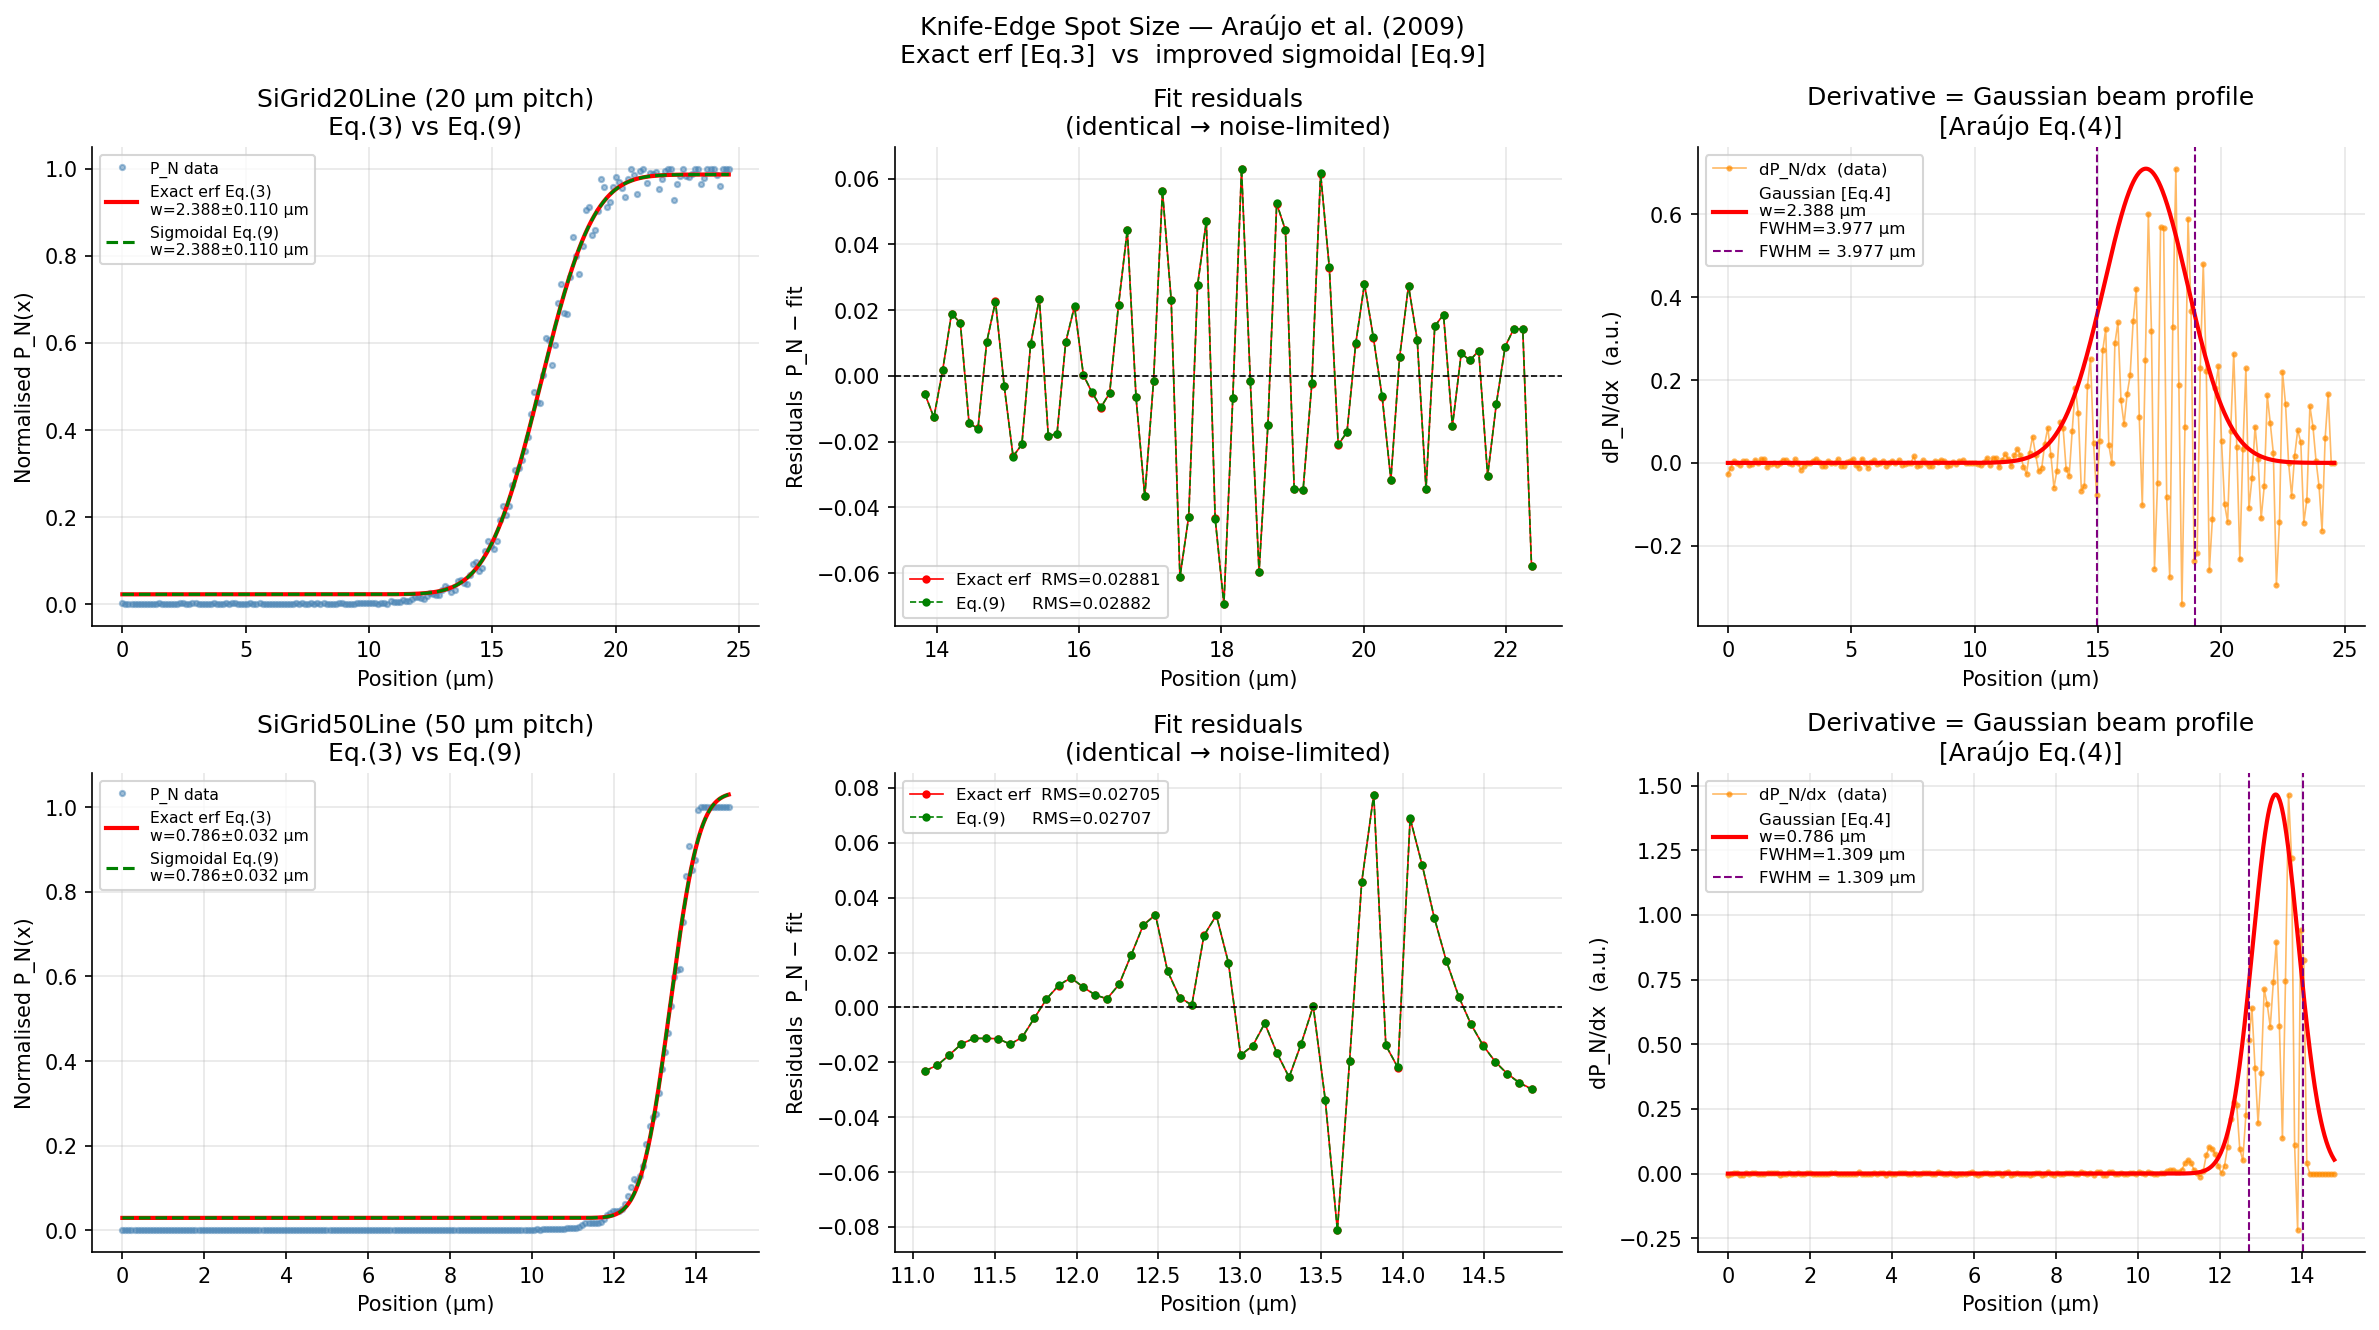


Saved: 11_araujo_analysis.png

════════════════════════════════════════════════════════════════════
  LASER BEAM RADIUS — Araújo et al. (2009) formalism
════════════════════════════════════════════════════════════════════
  Dataset                             w Eq3   w Eq9     w√2    FWHM      Δ%
  ────────────────────────────────────────────────────────────
  SiGrid20Line (20 µm pitch)          2.388   2.388   3.377   3.977  0.018%
  SiGrid50Line (50 µm pitch)          0.786   0.786   1.112   1.309  0.001%

  All units: µm
  w    = 1/e   intensity radius  [Araújo Eq.1]
  w√2  = 1/e²  intensity radius  [microscopy convention]
  FWHM = 2√(ln2)·w
  Δ%   = % difference Eq.(3) vs Eq.(9)  [expect < 0.01%]

  Best estimate (50 µm grid — bar width >> beam size):
    w        = 0.786 ± 0.032 µm
    w√2      = 1.112 µm
    FWHM     = 1.309 µm
    10–90%   = 1.425 µm

  20 µm grid gives w = 2.388 µm — larger because
  bar width (~10 µm) is comparable to beam size,
  violating Araújo's fully opa

In [4]:
# ── Cell 2: Knife-edge spot size — Araújo et al. (2009) ──────────────────────
# Fits the Si peak intensity edge profile from both line scan datasets.
# Two fitting models compared:
#   Eq.(3) — exact error function          (our primary result)
#   Eq.(9) — improved sigmoidal approx.    (cross-check, should agree to <0.01%)
#
# Physical positions loaded via rh.get_positions (reads .ompc XML)
# Si peak amplitudes loaded via rh.get_si_intensity (fits Lorentzian per spectrum)
# Edge profile normalised via normalise_profile (defined in Cell 1b)
# Transition window located via find_edge_window (defined in Cell 1b)
# Beam metrics computed via beam_size_from_w (defined in Cell 1b)
#
# Araújo functions pulled directly from rh:
#   rh.araujo_eq3  — exact erf [Eq.3]
#   rh.araujo_eq9  — improved sigmoidal [Eq.9]
#   rh.araujo_eq4  — derivative = Gaussian beam profile [Eq.4]
#
# Naming convention (saved to linescan_results.npz):
#   ls_{grid}_w_erf       → 1/e radius from exact erf (Araújo convention)
#   ls_{grid}_w_err       → 1-sigma fit uncertainty on w
#   ls_{grid}_w_1e2       → 1/e² radius  = w × √2
#   ls_{grid}_fwhm        → FWHM         = 2√(ln2) × w
#   ls_{grid}_w_1090      → 10%→90% edge width
#   ls_{grid}_w_eq9       → w from Eq.(9) — should match Eq.(3) to <0.01%
#   ls_{grid}_diff_pct    → % difference Eq.(3) vs Eq.(9)
#   ls_{grid}_rms_erf     → RMS residual of Eq.(3) fit
#   ls_{grid}_rms_eq9     → RMS residual of Eq.(9) fit
#   ls_{grid}_x0          → fitted edge centre position (µm)
#   ls_{grid}_scan_length → total scan length (µm)
#   ls_{grid}_step_size   → mean step size (µm)
#   ls_best_fwhm          → FWHM from the more reliable grid (50 µm)
#   ls_best_w             → w from the more reliable grid (50 µm)

# ── Dataset definitions ───────────────────────────────────────────────────────
datasets = [
    ("20um", "SiGrid20Line (20 µm pitch)",
     "SiGrid20Line.0.mat", "SiGrid20Line_Messposition.ompc"),
    ("50um", "SiGrid50Line (50 µm pitch)",
     "SiGrid50Line.0.mat", "SiGrid50Line_Messposition.ompc"),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    "Knife-Edge Spot Size — Araújo et al. (2009)\n"
    "Exact erf [Eq.3]  vs  improved sigmoidal [Eq.9]",
    fontsize=12
)

results_table = []
save_dict     = {}

for row, (grid_key, name, mat_path, ompc_path) in enumerate(datasets):

    print(f"\n{'='*60}")
    print(f"  {name}")

    # ── Step 1: Physical positions from .ompc via rh ──────────────────────
    pos = rh.get_positions(ompc_path)
    step_size   = float(np.diff(pos).mean())
    scan_length = float(pos.max())
    print(f"  Scan length : {scan_length:.2f} µm  over {len(pos)} steps")
    print(f"  Step size   : {step_size:.4f} µm")

    # ── Step 2: Si peak amplitude per spectrum via rh ─────────────────────
    print("  Fitting Si peaks ...")
    intensity = rh.get_si_intensity(mat_path)
    n_valid   = int(np.sum(~np.isnan(intensity)))
    print(f"  Valid fits  : {n_valid}/{len(intensity)}")

    # ── Step 3: Normalise 0→1 via helper ─────────────────────────────────
    norm  = normalise_profile(intensity)
    deriv = np.gradient(norm, pos)

    # ── Step 4: Locate transition window via helper ───────────────────────
    p_fit, n_fit, peak_idx = find_edge_window(pos, norm, pad=35)
    x0_guess = pos[peak_idx]

    # ── Step 5a: Fit exact erf — rh.araujo_eq3 ───────────────────────────
    fit_bounds = ([0.5, p_fit.min(), 0.05, -0.1],
                  [1.5, p_fit.max(), 15.0,  0.1])
    p0         = [1.0, x0_guess, 1.0, 0.0]

    erf_ok = False
    try:
        popt_erf, pcov_erf = curve_fit(
            rh.araujo_eq3, p_fit, n_fit,
            p0=p0, bounds=fit_bounds, maxfev=5000
        )
        perr_erf           = np.sqrt(np.diag(pcov_erf))
        I0_e, x0_e, w_e, bg_e = popt_erf
        erf_ok = True
    except RuntimeError:
        print("  Eq.(3) fit failed")

    # ── Step 5b: Fit improved sigmoidal — rh.araujo_eq9 ──────────────────
    eq9_ok = False
    try:
        popt_eq9, pcov_eq9 = curve_fit(
            rh.araujo_eq9, p_fit, n_fit,
            p0=p0, bounds=fit_bounds, maxfev=5000
        )
        perr_eq9           = np.sqrt(np.diag(pcov_eq9))
        I0_9, x0_9, w_9, bg_9 = popt_eq9
        eq9_ok = True
    except RuntimeError:
        print("  Eq.(9) fit failed")

    # ── Step 6: Beam size metrics via helper ──────────────────────────────
    if erf_ok:
        metrics  = beam_size_from_w(w_e)
        w_1e2    = metrics["w_1e2"]
        fwhm     = metrics["fwhm"]
        w_1090   = metrics["w_1090"]
        diff_pct = float(100 * abs(w_e - w_9) / w_e) if eq9_ok else np.nan

        # Residuals
        res_erf = n_fit - rh.araujo_eq3(p_fit, *popt_erf)
        rms_erf = float(np.sqrt(np.mean(res_erf**2)))
        if eq9_ok:
            res_eq9 = n_fit - rh.araujo_eq9(p_fit, *popt_eq9)
            rms_eq9 = float(np.sqrt(np.mean(res_eq9**2)))
        else:
            res_eq9 = None
            rms_eq9 = np.nan

        print(f"\n  Araújo Eq.(3) — exact erf:")
        print(f"    w  (1/e radius) = {w_e:.4f} ± {perr_erf[2]:.4f} µm")
        print(f"    w√2 (1/e² rad)  = {w_1e2:.4f} µm")
        print(f"    FWHM            = {fwhm:.4f} µm")
        print(f"    10–90% width    = {w_1090:.4f} µm")
        print(f"    RMS residual    = {rms_erf:.5f}")
        if eq9_ok:
            print(f"\n  Araújo Eq.(9) — improved sigmoidal:")
            print(f"    w  (1/e radius) = {w_9:.4f} ± {perr_eq9[2]:.4f} µm")
            print(f"    Δ vs Eq.(3)     = {diff_pct:.4f}%")

        results_table.append({
            "name"    : name,
            "w_erf"   : w_e,   "w_erf_err": perr_erf[2],
            "w_eq9"   : w_9 if eq9_ok else np.nan,
            "w_1e2"   : w_1e2, "fwhm"     : fwhm,
            "w_1090"  : w_1090,"diff_pct"  : diff_pct,
        })

        # Collect for save
        save_dict.update({
            f"ls_{grid_key}_w_erf"      : float(w_e),
            f"ls_{grid_key}_w_err"      : float(perr_erf[2]),
            f"ls_{grid_key}_w_eq9"      : float(w_9) if eq9_ok else np.nan,
            f"ls_{grid_key}_w_1e2"      : float(w_1e2),
            f"ls_{grid_key}_fwhm"       : float(fwhm),
            f"ls_{grid_key}_w_1090"     : float(w_1090),
            f"ls_{grid_key}_diff_pct"   : float(diff_pct),
            f"ls_{grid_key}_rms_erf"    : rms_erf,
            f"ls_{grid_key}_rms_eq9"    : rms_eq9,
            f"ls_{grid_key}_x0"         : float(x0_e),
            f"ls_{grid_key}_scan_length": scan_length,
            f"ls_{grid_key}_step_size"  : step_size,
            f"ls_{grid_key}_n_valid"    : n_valid,
        })

    # ── Plot column 1: normalised profile + both fits ─────────────────────
    ax     = axes[row, 0]
    x_fine = np.linspace(pos.min(), pos.max(), 1000)
    ax.plot(pos, norm, "o", ms=2.5, color="steelblue",
            alpha=0.5, label="P_N data")
    if erf_ok:
        ax.plot(x_fine, rh.araujo_eq3(x_fine, *popt_erf),
                "r-", lw=2,
                label=f"Exact erf Eq.(3)\nw={w_e:.3f}±{perr_erf[2]:.3f} µm")
    if eq9_ok:
        ax.plot(x_fine, rh.araujo_eq9(x_fine, *popt_eq9),
                "g--", lw=1.5,
                label=f"Sigmoidal Eq.(9)\nw={w_9:.3f}±{perr_eq9[2]:.3f} µm")
    ax.set_xlabel("Position (µm)")
    ax.set_ylabel("Normalised P_N(x)")
    ax.set_title(f"{name}\nEq.(3) vs Eq.(9)")
    ax.legend(fontsize=7.5)

    # ── Plot column 2: residuals ───────────────────────────────────────────
    ax = axes[row, 1]
    if erf_ok:
        ax.plot(p_fit, res_erf, "r-o", ms=3, lw=0.8,
                label=f"Exact erf  RMS={rms_erf:.5f}")
    if eq9_ok and res_eq9 is not None:
        ax.plot(p_fit, res_eq9, "g--o", ms=3, lw=0.8,
                label=f"Eq.(9)     RMS={rms_eq9:.5f}")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel("Position (µm)")
    ax.set_ylabel("Residuals  P_N − fit")
    ax.set_title("Fit residuals\n(identical → noise-limited)")
    ax.legend(fontsize=8)

    # ── Plot column 3: derivative = beam profile [rh.araujo_eq4] ─────────
    ax = axes[row, 2]
    ax.plot(pos, deriv, "o-", ms=2, lw=0.8,
            color="darkorange", alpha=0.6, label="dP_N/dx  (data)")
    if erf_ok:
        gauss_theory = rh.araujo_eq4(x_fine, 1.0, x0_e, w_e)
        scale        = deriv.max() / gauss_theory.max()
        ax.plot(x_fine, scale * gauss_theory,
                "r-", lw=2,
                label=f"Gaussian [Eq.4]\nw={w_e:.3f} µm\nFWHM={fwhm:.3f} µm")
        ax.axvline(x0_e - fwhm/2, color="purple", lw=1, ls="--")
        ax.axvline(x0_e + fwhm/2, color="purple", lw=1, ls="--",
                   label=f"FWHM = {fwhm:.3f} µm")
    ax.set_xlabel("Position (µm)")
    ax.set_ylabel("dP_N/dx  (a.u.)")
    ax.set_title("Derivative = Gaussian beam profile\n[Araújo Eq.(4)]")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("11_araujo_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: 11_araujo_analysis.png")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "═"*68)
print("  LASER BEAM RADIUS — Araújo et al. (2009) formalism")
print("═"*68)
print(f"  {'Dataset':<33} {'w Eq3':>7} {'w Eq9':>7} "
      f"{'w√2':>7} {'FWHM':>7} {'Δ%':>7}")
print("  " + "─"*60)
for r in results_table:
    print(f"  {r['name']:<33} {r['w_erf']:>7.3f} "
          f"{r['w_eq9']:>7.3f} {r['w_1e2']:>7.3f} "
          f"{r['fwhm']:>7.3f} {r['diff_pct']:>6.3f}%")
print()
print("  All units: µm")
print("  w    = 1/e   intensity radius  [Araújo Eq.1]")
print("  w√2  = 1/e²  intensity radius  [microscopy convention]")
print("  FWHM = 2√(ln2)·w")
print("  Δ%   = % difference Eq.(3) vs Eq.(9)  [expect < 0.01%]")

# ── Best estimate (50 µm grid is more reliable) ───────────────────────────────
if len(results_table) == 2:
    r50 = results_table[1]   # 50 µm grid
    r20 = results_table[0]   # 20 µm grid
    print(f"\n  Best estimate (50 µm grid — bar width >> beam size):")
    print(f"    w        = {r50['w_erf']:.3f} ± {r50['w_erf_err']:.3f} µm")
    print(f"    w√2      = {r50['w_1e2']:.3f} µm")
    print(f"    FWHM     = {r50['fwhm']:.3f} µm")
    print(f"    10–90%   = {r50['w_1090']:.3f} µm")
    print(f"\n  20 µm grid gives w = {r20['w_erf']:.3f} µm — larger because")
    print(f"  bar width (~10 µm) is comparable to beam size,")
    print(f"  violating Araújo's fully opaque knife-edge assumption.")

    save_dict["ls_best_w"]    = float(r50["w_erf"])
    save_dict["ls_best_w_err"]= float(r50["w_erf_err"])
    save_dict["ls_best_w_1e2"]= float(r50["w_1e2"])
    save_dict["ls_best_fwhm"] = float(r50["fwhm"])
    save_dict["ls_best_w_1090"]= float(r50["w_1090"])
    save_dict["ls_best_grid"] = "50um"

print("═"*68)

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(**save_dict)